### importing required libraries or packages

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

### Importing dataset

In [36]:
df = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\Project\Disaster Emergency Response.csv")
df

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,2021-01-31,Brazil,Earthquake,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,2018-12-23,Brazil,Extreme Heat,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,2020-08-10,India,Hurricane,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,2022-09-15,Indonesia,Extreme Heat,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,2022-09-28,United States,Wildfire,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2019-05-14,Chile,Landslide,5.50,78,3711240.93,8.45,305020.35,94.27,55,12.976,-25.680
49996,2020-10-30,United States,Wildfire,7.76,165,12072842.65,1.00,363881.25,95.46,76,57.265,-147.346
49997,2019-04-27,Turkey,Flood,4.90,130,1805859.70,5.14,280665.61,86.67,47,15.217,-27.856
49998,2022-10-09,Greece,Storm Surge,3.35,82,3176085.56,19.22,80331.23,84.75,32,-44.002,1.923


In [37]:
df.columns

Index(['date', 'country', 'disaster_type', 'severity_index', 'casualties',
       'economic_loss_usd', 'response_time_hours', 'aid_amount_usd',
       'response_efficiency_score', 'recovery_days', 'latitude', 'longitude'],
      dtype='object')

In [38]:
#PREPROCESSING

In [39]:
df.isnull().sum()

date                         0
country                      0
disaster_type                0
severity_index               0
casualties                   0
economic_loss_usd            0
response_time_hours          0
aid_amount_usd               0
response_efficiency_score    0
recovery_days                0
latitude                     0
longitude                    0
dtype: int64

In [40]:
df.describe()

,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
count,50000.000000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000
mean,5.015769,100.591140,5.068593e+06,12.183027,2.500003e+05,87.574025,49.682560,0.231205,0.089889
std,1.942843,65.052064,3.268541e+06,9.259081,1.432275e+05,10.188961,20.098944,34.759662,98.380208
min,1.000000,0.000000,5.273900e+02,1.000000,1.660000e+01,29.750000,2.000000,-59.994000,-169.998000
25%,3.660000,51.000000,2.585513e+06,6.270000,1.429663e+05,83.060000,36.000000,-29.848250,-85.551750
50%,4.990000,91.000000,4.548351e+06,10.510000,2.305365e+05,89.180000,49.000000,0.267500,0.390500
75%,6.340000,138.000000,6.950615e+06,15.450000,3.352259e+05,94.700000,63.000000,30.488250,85.665000
max,10.000000,524.000000,2.445624e+07,63.100000,1.126465e+06,100.000000,112.000000,59.997000,169.999000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       50000 non-null  object 
 1   country                    50000 non-null  object 
 2   disaster_type              50000 non-null  object 
 3   severity_index             50000 non-null  float64
 4   casualties                 50000 non-null  int64  
 5   economic_loss_usd          50000 non-null  float64
 6   response_time_hours        50000 non-null  float64
 7   aid_amount_usd             50000 non-null  float64
 8   response_efficiency_score  50000 non-null  float64
 9   recovery_days              50000 non-null  int64  
 10  latitude                   50000 non-null  float64
 11  longitude                  50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


In [42]:
df.head()

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,2021-01-31,Brazil,Earthquake,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,2018-12-23,Brazil,Extreme Heat,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,2020-08-10,India,Hurricane,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,2022-09-15,Indonesia,Extreme Heat,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,2022-09-28,United States,Wildfire,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137


In [43]:
df.tail()

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
49995,2019-05-14,Chile,Landslide,5.50,78,3711240.93,8.45,305020.35,94.27,55,12.976,-25.680
49996,2020-10-30,United States,Wildfire,7.76,165,12072842.65,1.00,363881.25,95.46,76,57.265,-147.346
49997,2019-04-27,Turkey,Flood,4.90,130,1805859.70,5.14,280665.61,86.67,47,15.217,-27.856
49998,2022-10-09,Greece,Storm Surge,3.35,82,3176085.56,19.22,80331.23,84.75,32,-44.002,1.923
49999,2023-01-12,South Africa,Drought,5.03,129,2933495.70,9.08,354096.99,97.16,50,13.084,-81.048


In [44]:
df.disaster_type.unique()

array(['Earthquake', 'Extreme Heat', 'Hurricane', 'Wildfire', 'Flood',
       'Storm Surge', 'Drought', 'Tornado', 'Landslide',
       'Volcanic Eruption'], dtype=object)

<Axes: xlabel='disaster_type', ylabel='count'>

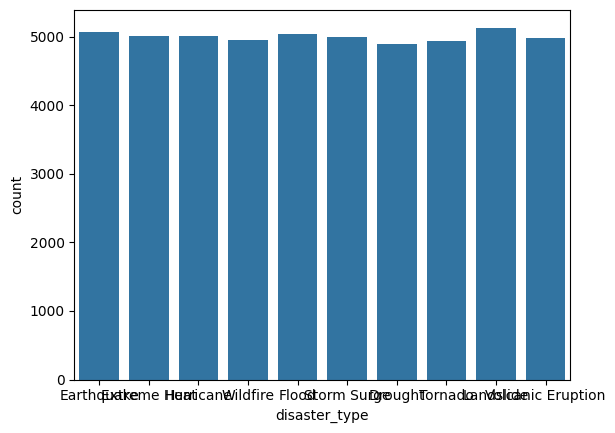

In [45]:
sns.countplot(x = 'disaster_type', data = df)

<Axes: >

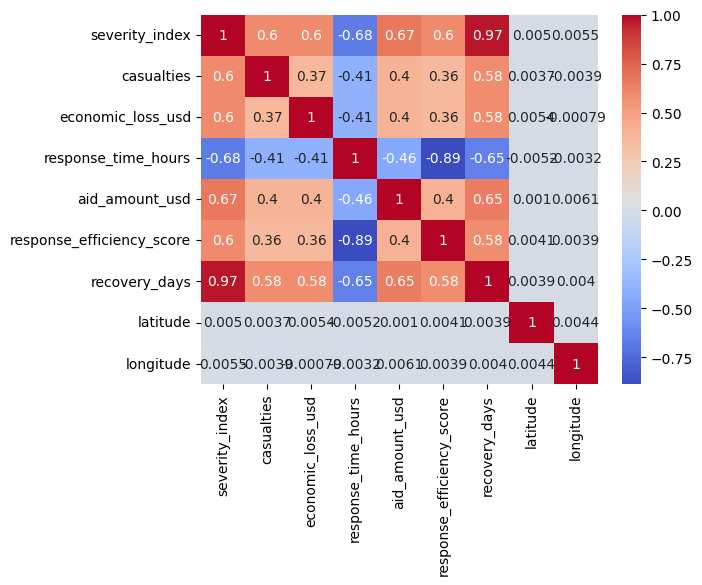

In [46]:
sns.heatmap(df.select_dtypes('number').corr(),annot=True,cmap='coolwarm')

In [47]:
LE =  LabelEncoder()
df['date']=LE.fit_transform(df['date'])
df['country']=LE.fit_transform(df['country'])
df['disaster_type']=LE.fit_transform(df['disaster_type'])

In [48]:
df.response_efficiency_score.unique()

array([83.21, 96.18, 60.4 , ..., 57.41, 42.09, 56.46])

In [49]:
df

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,1126,2,1,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,356,2,2,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,952,9,4,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,1718,10,2,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,1731,19,9,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,498,4,5,5.50,78,3711240.93,8.45,305020.35,94.27,55,12.976,-25.680
49996,1033,19,9,7.76,165,12072842.65,1.00,363881.25,95.46,76,57.265,-147.346
49997,481,18,3,4.90,130,1805859.70,5.14,280665.61,86.67,47,15.217,-27.856
49998,1742,8,6,3.35,82,3176085.56,19.22,80331.23,84.75,32,-44.002,1.923


<Axes: xlabel='disaster_type', ylabel='count'>

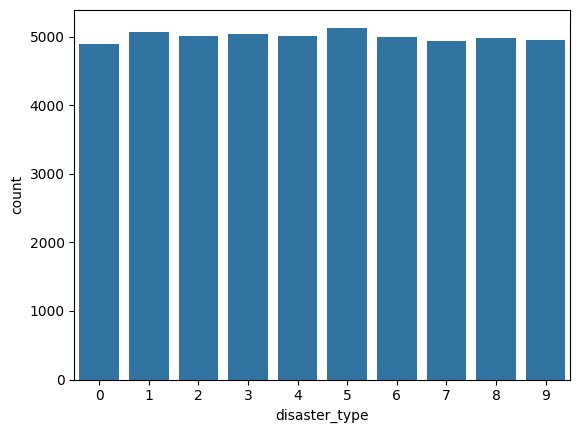

In [50]:
sns.countplot(x = 'disaster_type', data = df)

In [51]:
#y = df.iloc[:,-1]
#y

y = df['recovery_days']
y

0        67
1        55
2        22
3        47
4        42
         ..
49995    55
49996    76
49997    47
49998    32
49999    50
Name: recovery_days, Length: 50000, dtype: int64

In [52]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df.drop("date", axis=1, inplace=True)
df

,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude,year,month
0,2,1,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557,1970,1
1,2,2,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194,1970,1
2,9,4,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978,1970,1
3,10,2,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350,1970,1
4,19,9,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137,1970,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,4,5,5.50,78,3711240.93,8.45,305020.35,94.27,55,12.976,-25.680,1970,1
49996,19,9,7.76,165,12072842.65,1.00,363881.25,95.46,76,57.265,-147.346,1970,1
49997,18,3,4.90,130,1805859.70,5.14,280665.61,86.67,47,15.217,-27.856,1970,1
49998,8,6,3.35,82,3176085.56,19.22,80331.23,84.75,32,-44.002,1.923,1970,1


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

def preprocess_and_scale_features(df, target_cols=["response_efficiency_score", "recovery_days"]):
    df = df.copy()

    # Separate categorical and numeric columns
    cat_cols = ["country", "disaster_type"]
    num_cols = df.select_dtypes(include=["int32", "int64", "float64"]).columns
    num_cols = [c for c in num_cols if c not in target_cols]  # exclude target columns

    # Label encode categorical features
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col]=le
        scaler=StandardScaler()
        df[num_cols]=scaler.fit_transform(df[num_cols])

        return df,scaler,label_encoders

In [54]:
df, scaler, label_encoders = preprocess_and_scale_features(df)

In [55]:
#EXPLORATORY DATA ANALYSIS

In [56]:
def disaster_eda_plots(df):

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    disaster_counts = df['disaster_type'].value_counts()
    sns.barplot(x=disaster_counts.index, y=disaster_counts.values, ax=axes[0])
    axes[0].set_title("Disaster Type Frequency")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

    axes[1].pie(
        disaster_counts.values,
        labels=disaster_counts.index,
        autopct='%1.1f%%'
    )
    axes[1].set_title("Disaster Type Share")
    
    plt.tight_layout()
    plt.show()
    
    country_count = df['country'].value_counts().head(10)
    
    plt.figure(figsize=(10,5))
    sns.barplot(x=country_count.index, y=country_count.values)
    plt.xticks(rotation=45)
    plt.title("Top 10 Most Impacted Countries")
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    
    sns.distplot(df['casualties'], kde=True, ax=axes[0])
    axes[0].set_title("Casualties Distribution")

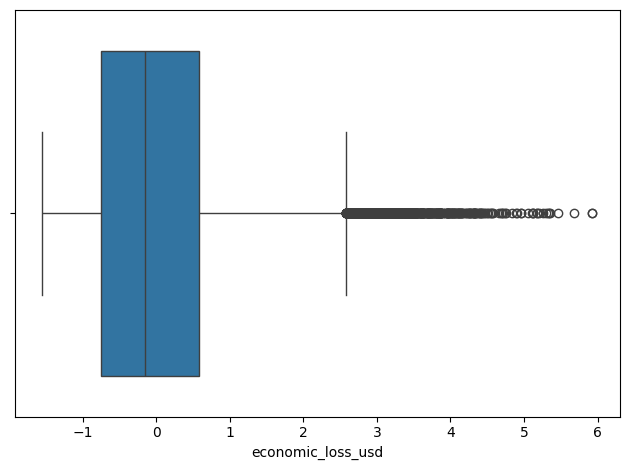

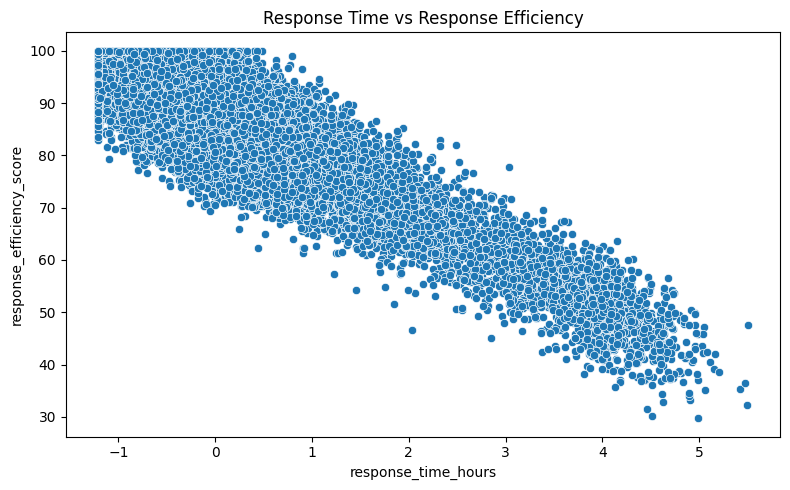

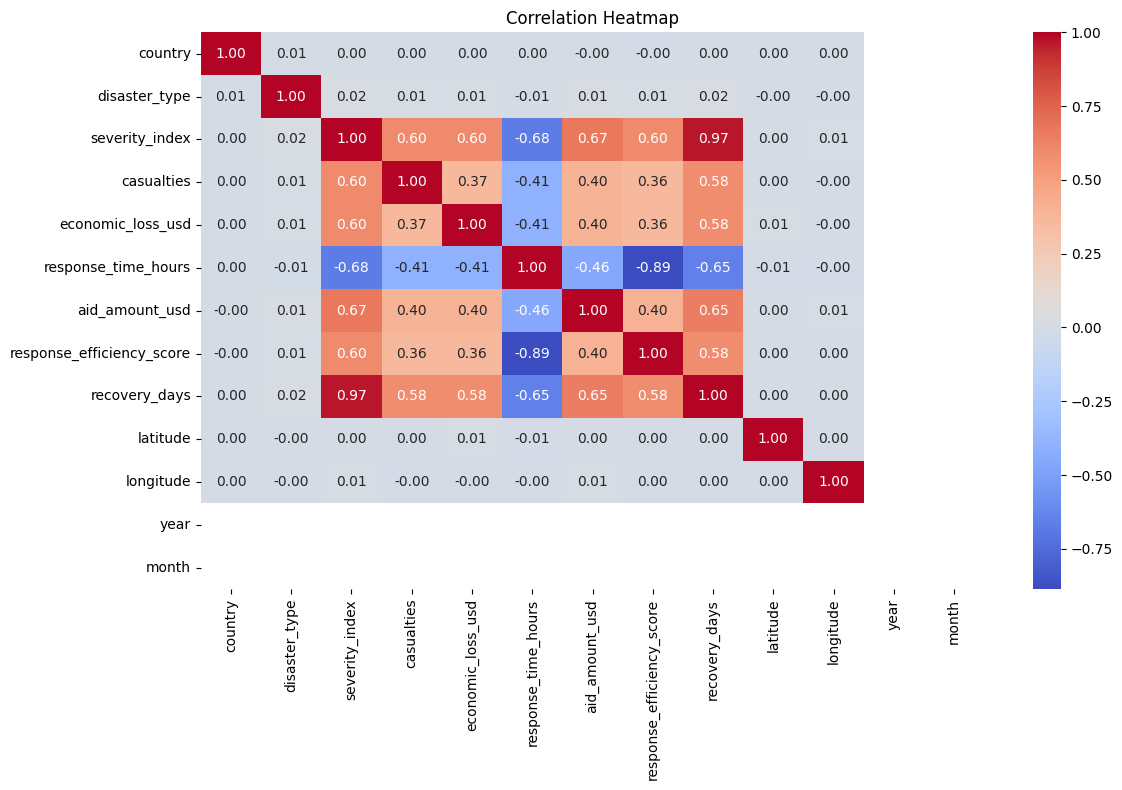

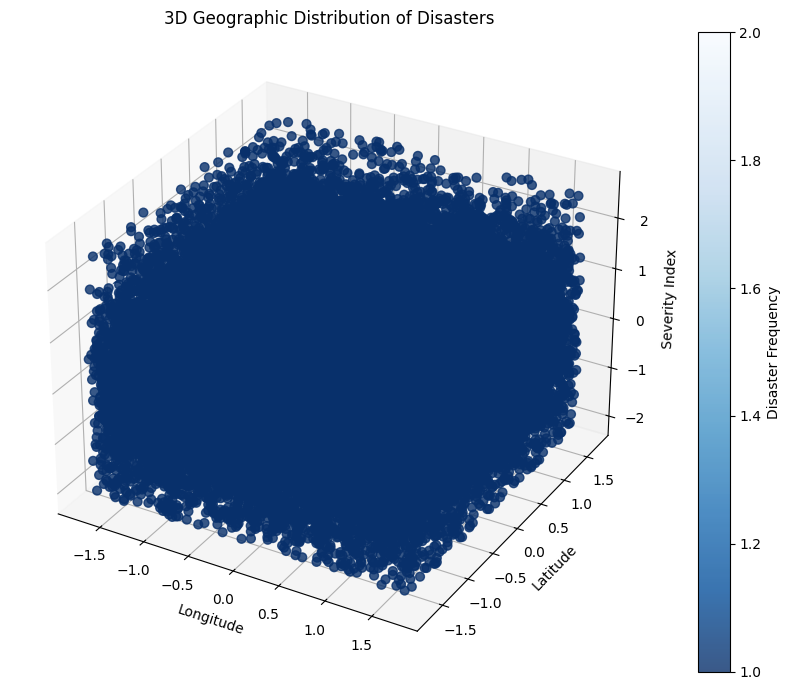

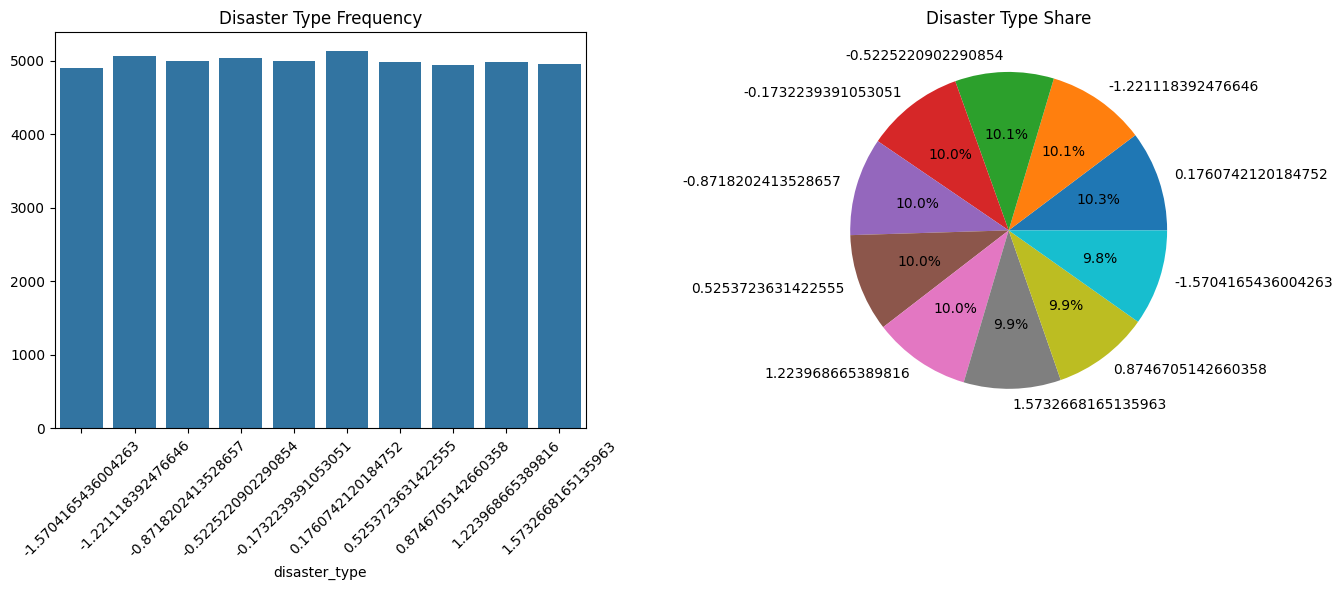

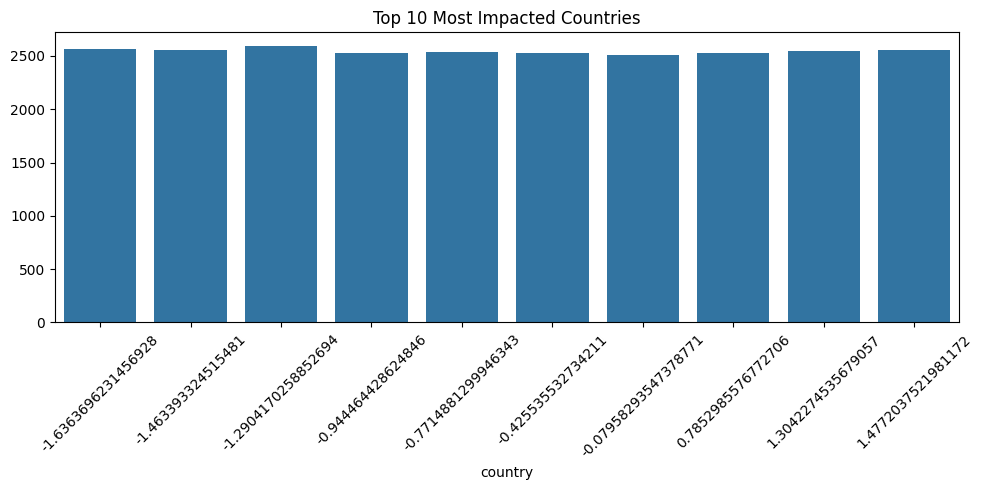

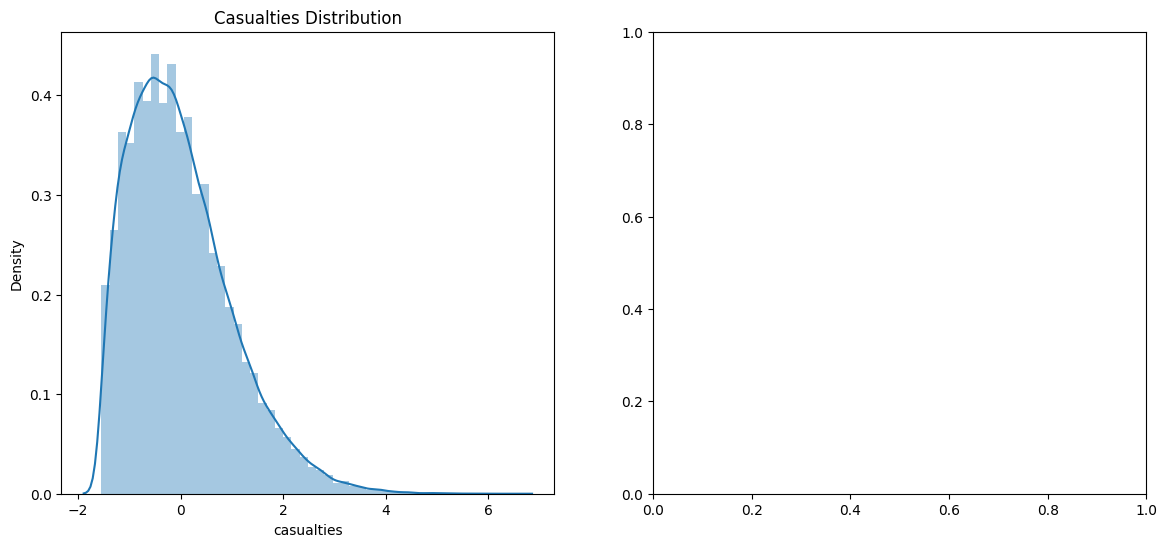

In [57]:
sns.boxplot(x=df['economic_loss_usd'])

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='response_time_hours', y='response_efficiency_score')
plt.title("Response Time vs Response Efficiency")
plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

location_counts = df.groupby(['latitude', 'longitude']).size().reset_index(name='count')
df_3d = df.merge(location_counts, on=['latitude', 'longitude'], how='left')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_3d['longitude'],
    df_3d['latitude'],
    df_3d['severity_index'],
    c=df_3d['count'],
    s=df_3d['count'] * 40,
    cmap='Blues_r',
    alpha=0.8
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Severity Index')
ax.set_title('3D Geographic Distribution of Disasters')

fig.colorbar(scatter, ax=ax, label='Disaster Frequency')
plt.tight_layout()
plt.show()

disaster_eda_plots(df)

bins=[0,60,80,100]
labels=["Low","Medium","High"]

df["response_efficiency_score"]=pd.cut(
    df["response_efficiency_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [58]:
#SPLITTING DATA FOR MODEL TRAINING

In [59]:
X=df.drop(["response_efficiency_score", "recovery_days"],axis=1)
y_class=df["response_efficiency_score"]
y_reg=df["recovery_days"]

X_train,X_test,y_class_train,y_class_test,y_reg_train,y_reg_test=train_test_split(
    X,y_class,y_reg,test_size=0.2,random_state=42
)

In [60]:
cls_names=[]
Accuracy_list=[]
Precision_list=[]
Recall_list=[]
F1_list=[]
AUC_list=[]

reg_names=[]
R2_list=[]
MAE_list=[]
RMSE_list=[]

In [61]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

def calculate_metrics(
    task_type,
    algorithm,
    y_test,
    preds,
    probs=None
):
    """
    task_type: 'classification' or 'regression'
    """
    #=========CLASSIFICATION==========#
    if task_type=='classification':
        acc=accuracy_score(y_test,preds)
        prec=precision_score(y_test,preds,average="weighted",zero_division=0)
        rec = recall_score(y_test, preds, average="weighted", zero_division=0)
        f1 = f1_score(y_test, preds, average="weighted", zero_division=0)
    
        if probs is not None and hasattr(probs, "ndim") and probs.ndim == 2:
            auc = roc_auc_score(y_test, probs, multi_class="ovr")
        else:
            auc = np.nan
        
        cls_names.append(algorithm)
        Accuracy_list.append(acc)
        Precision_list.append(prec)
        Recall_list.append(rec)
        F1_list.append(f1)
        AUC_list.append(auc)
        
        print(algorithm)
        print(f"Accuracy  : {acc:.4f}")
        print(f"Precision : {prec:.4f}")
        print(f"Recall    : {rec:.4f}")
        print(f"F1-score  : {f1:.4f}")
        if not np.isnan(auc):
            print(f"AUC       : {auc:.4f}")
        print("-" * 40)
    
        #===========REGRESSION=========#
    elif task_type == "regression":
    
        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
    
        reg_names.append(algorithm)
        R2_list.append(r2)
        MAE_list.append(mae)
        RMSE_list.append(rmse)
    
        print(algorithm)
        print(f"R2   : {r2:.4f}")
        print(f"MAE  : {mae:.4f}")
        print(f"RMSE : {rmse:.4f}")
        print("-" * 40)
    
        os.makedirs("results", exist_ok=True)
    
        plt.figure(figsize=(6, 5))
        plt.scatter(y_test, preds, alpha=0.6)
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            linestyle="--"
        )
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{algorithm}:Actual vs Predicted")
        plt.tight_layout()
        plt.savefig(
            f"results/{algorithm.replace(' ','_').lower()}_actual_vs_pred.png"
        )
        plt.show()

In [62]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    class_labels,
    title="Confusion Matrix"
):
    cm=confusion_matrix(y_true,y_pred,labels=class_labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [63]:
def plot_regression_comparison():
    if len(reg_names) == 0:
        print("No regression metrics available")
        return
    data_len = min(
    len(reg_names),
    len(R2_list),
    len(MAE_list),
    len(RMSE_list)
    )
    
    x = np.arange(data_len)
    w = 0.25
    
    plt.figure(figsize=(14,6))
    plt.bar(x - w, R2_list[:data_len], w, label="R2")
    plt.bar(x, MAE_list[:data_len], w, label="MAE")
    plt.bar(x + w, RMSE_list[:data_len], w, label="RMSE")
    
    plt.xticks(x, reg_names[:data_len], rotation=20)
    plt.ylabel("Score")
    plt.title("Regression Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()



In [64]:
#MODEL BUILDING AND TRAINING

In [65]:
#DECISION TREE

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error

def decision_tree_model(
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test,
    folder="models",
    max_depth=5,
    random_state=42,
    class_labels=("Low", "Medium", "High")
):

    os.makedirs(folder, exist_ok=True)

    # ============== CLASSIFICATION ==============
    clf_path = f"{folder}/decision_tree_classifier.pkl"

    if os.path.exists(clf_path):
        dt_clf = joblib.load(clf_path)
    else:
        dt_clf = DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=random_state
        )
        dt_clf.fit(X_train, y_class_train)
        joblib.dump(dt_clf, clf_path)

    clf_preds = dt_clf.predict(X_test)
    
    # Safe probability handling
    clf_probs = (
        dt_clf.predict_proba(X_test)
        if hasattr(dt_clf, "predict_proba")
        else None
    )
    
    calculate_metrics(
        task_type="classification",
        algorithm="Decision Tree",
        y_test=y_class_test,
        preds=clf_preds,
        probs=clf_probs
    )
    plot_confusion_matrix(
        y_class_test,
        clf_preds,
        class_labels,
        title="Decision Tree 🔲 Confusion Matrix"
    )
    
    # =================== REGRESSION ===================
    reg_path = f"{folder}/decision_tree_regressor.pkl"
    
    if os.path.exists(reg_path):
        dt_reg = joblib.load(reg_path)
    else:
        dt_reg = DecisionTreeRegressor(
            max_depth=max_depth,
            random_state=random_state
        )
        dt_reg.fit(X_train, y_reg_train)
        joblib.dump(dt_reg, reg_path)
    
    reg_preds = dt_reg.predict(X_test)
    
    calculate_metrics(
        task_type="regression",
        algorithm="Decision Tree",
        y_test=y_reg_test,
        preds=reg_preds
    )

    return dt_clf,dt_reg


Decision Tree
Accuracy  : 0.9072
Precision : 0.8990
Recall    : 0.9072
F1-score  : 0.8989
AUC       : 0.9522
----------------------------------------


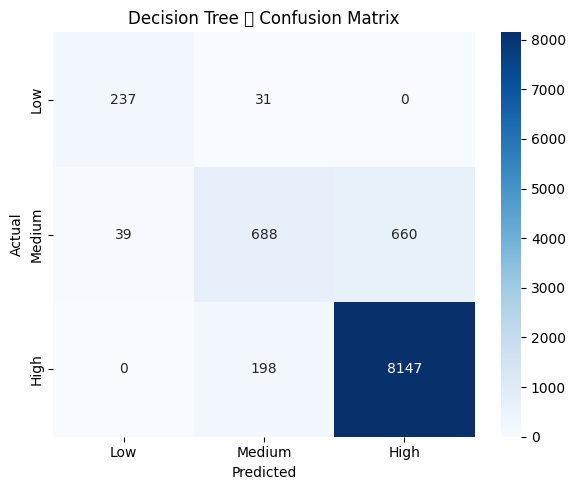

Decision Tree
R2   : 0.9369
MAE  : 4.0324
RMSE : 5.0613
----------------------------------------


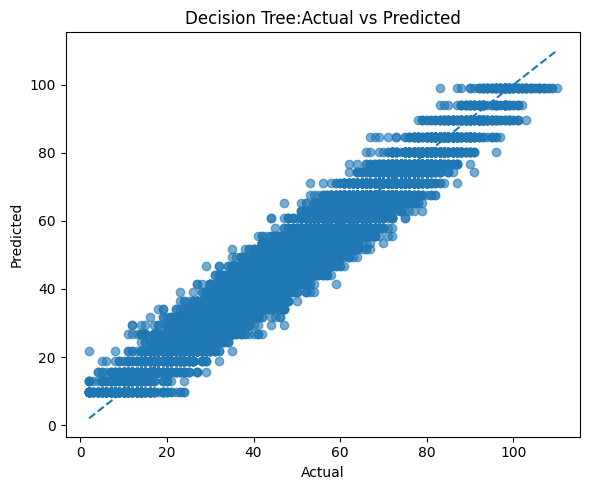

In [67]:
dt_clf, dt_reg = decision_tree_model(
        X_train, X_test,
        y_class_train, y_class_test,
        y_reg_train, y_reg_test,
        max_depth=5
    )

In [68]:
#SGD

In [69]:
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import SGDRegressor

def sgd_model(
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test,
    folder="models",
    random_state=42,
    class_labels=("Low", "Medium", "High")
):

    os.makedirs(folder, exist_ok=True)

    # -------- Classification --------
    clf_path = f"{folder}/sgd_classifier.pkl"

    if os.path.exists(clf_path):
        sgd_clf = joblib.load(clf_path)
    else:
        sgd_clf = SGDClassifier(
            loss="log_loss",
            alpha=0.1,
            max_iter=1000,
            random_state=random_state
        )

        sgd_clf.fit(X_train, y_class_train)
        joblib.dump(sgd_clf, clf_path)
        
    clf_preds = sgd_clf.predict(X_test)
    clf_probs = sgd_clf.predict_proba(X_test)
    
    calculate_metrics(
        "classification", "SGD",
        y_class_test, clf_preds, clf_probs
    )
    
    plot_confusion_matrix(
        y_class_test,
        clf_preds,
        class_labels,
        title="SGD 🤖 Confusion Matrix"
    )
    
    # -------- Regression --------
    reg_path = f"{folder}/sgd_regressor.pkl"
    
    if os.path.exists(reg_path):
        sgd_reg = joblib.load(reg_path)
    else:
        sgd_reg = SGDRegressor(
            loss="squared_error",
            alpha=0.5,
            max_iter=1000,
            random_state=random_state
        )
        sgd_reg.fit(X_train, y_reg_train)
        joblib.dump(sgd_reg, reg_path)
    
    reg_preds = sgd_reg.predict(X_test)
    
    calculate_metrics(
        "regression", "SGD",
        y_reg_test, reg_preds
    )
    
    return sgd_clf, sgd_reg


SGD
Accuracy  : 0.8542
Precision : 0.7895
Recall    : 0.8542
F1-score  : 0.8086
AUC       : 0.9217
----------------------------------------


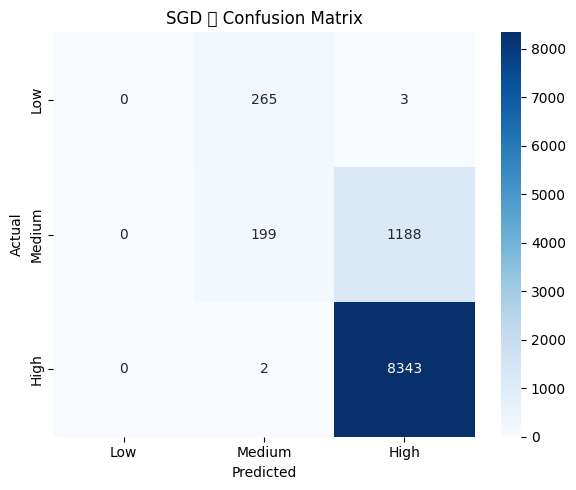

SGD
R2   : 0.8510
MAE  : 6.1495
RMSE : 7.7786
----------------------------------------


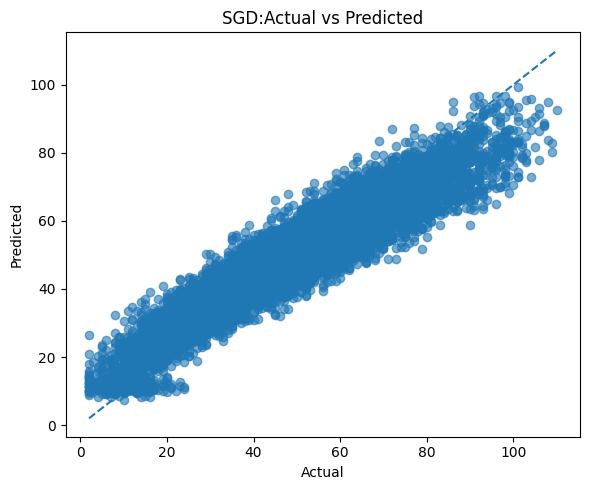

In [70]:
sgd_clf,sgd_reg=sgd_model(
    X_train, X_test,
    y_class_train,y_class_test,
    y_reg_train,y_reg_test
)

In [71]:
#ADA BOOST

In [72]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor

def adaboost_model(
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test,
    folder="models",
    random_state=42,
    class_labels=("Low", "Medium", "High")
):

    os.makedirs(folder, exist_ok=True)

    # =============== CLASSIFICATION ===============
    clf_path = f"{folder}/adaboost_classifier.pkl"

    if os.path.exists(clf_path):
        ada_clf = joblib.load(clf_path)
    else:
        ada_clf = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100,
            learning_rate=0.5,
            random_state=random_state
        )

        ada_clf.fit(X_train, y_class_train)
        joblib.dump(ada_clf, clf_path)

    clf_preds = ada_clf.predict(X_test)
    clf_probs = ada_clf.predict_proba(X_test)

    calculate_metrics(
        task_type="classification",
        algorithm="AdaBoost",
        y_test=y_class_test,
        preds=clf_preds,
        probs=clf_probs
    )

    plot_confusion_matrix(
        y_class_test,
        clf_preds,
        class_labels,
        title="AdaBoost 🔲 Confusion Matrix"
    )

    # ============== REGRESSION ==============
    reg_path = f"{folder}/adaboost_regressor.pkl"

    if os.path.exists(reg_path):
        ada_reg = joblib.load(reg_path)
    else:
        ada_reg = AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=1),
            n_estimators=100,
            learning_rate=0.5,
            random_state=random_state
        )
        ada_reg.fit(X_train, y_reg_train)
        joblib.dump(ada_reg, reg_path)

    reg_preds = ada_reg.predict(X_test)

    calculate_metrics(
        task_type="regression",
        algorithm="AdaBoost",
        y_test=y_reg_test,
        preds=reg_preds
    )

    return ada_clf, ada_reg


AdaBoost
Accuracy  : 0.9046
Precision : 0.9014
Recall    : 0.9046
F1-score  : 0.9026
AUC       : 0.9029
----------------------------------------


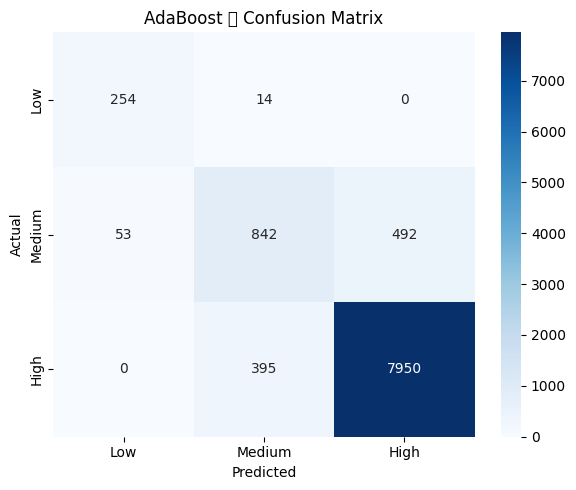

AdaBoost
R2   : 0.7401
MAE  : 8.0294
RMSE : 10.2723
----------------------------------------


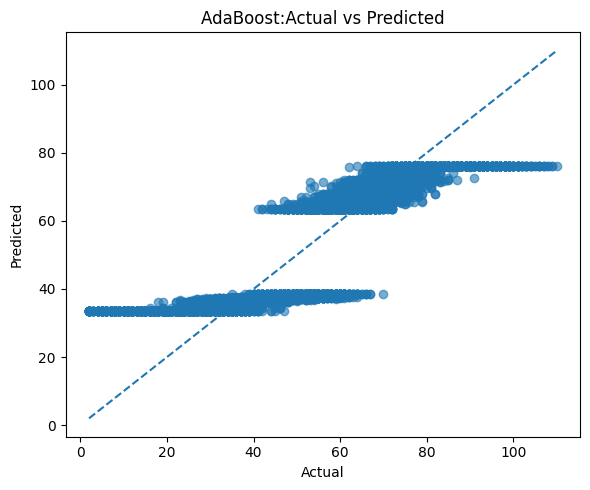

In [73]:
ada_clf, ada_reg = adaboost_model(
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test
)


In [74]:
#CAT BOOST

In [75]:
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor

def catboost_model(
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test,
    folder="models",
    random_state=42,
    class_labels=("Low", "Medium", "High")
):
    os.makedirs(folder, exist_ok=True)

    # ================= CLASSIFICATION =================
    clf_path = f"{folder}/catboost_classifier.pkl"

    if os.path.exists(clf_path):
        cat_clf = joblib.load(clf_path)
    else:
        cat_clf = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=random_state,
            verbose=0
        )

        cat_clf.fit(X_train, y_class_train)
        joblib.dump(cat_clf, clf_path)

    clf_preds = cat_clf.predict(X_test)
    clf_probs = cat_clf.predict_proba(X_test)

    calculate_metrics(
        task_type="classification",
        algorithm="CatBoost",
        y_test=y_class_test,
        preds=clf_preds,
        probs=clf_probs
    )

    plot_confusion_matrix(
        y_class_test,
        clf_preds,
        class_labels,
        title="CatBoost 📊 Confusion Matrix"
    )

    # ================ REGRESSION ================
    reg_path = f"{folder}/catboost_reg"

    if os.path.exists(reg_path):
        cat_reg = joblib.load(reg_path)
    else:
        cat_reg = CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=random_state,
            verbose=0
        )
        cat_reg.fit(X_train, y_reg_train)
        joblib.dump(cat_reg, reg_path)

    reg_preds = cat_reg.predict(X_test)

    calculate_metrics(
        task_type="regression",
        algorithm="CatBoost",
        y_test=y_reg_test,
        preds=reg_preds
    )

    return cat_clf, cat_reg


CatBoost
Accuracy  : 0.9095
Precision : 0.9025
Recall    : 0.9095
F1-score  : 0.9037
AUC       : 0.9549
----------------------------------------


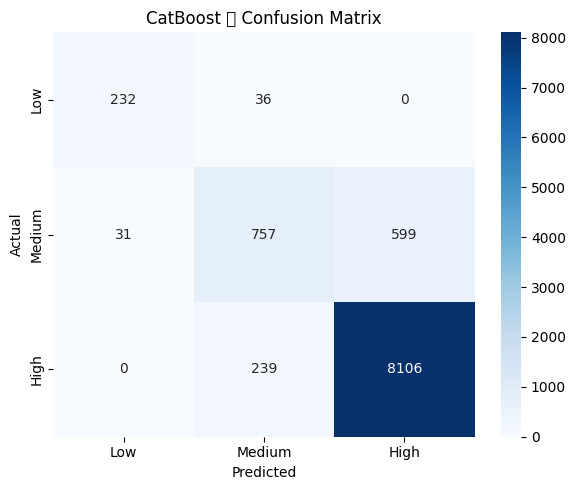

CatBoost
R2   : 0.9380
MAE  : 3.9965
RMSE : 5.0157
----------------------------------------


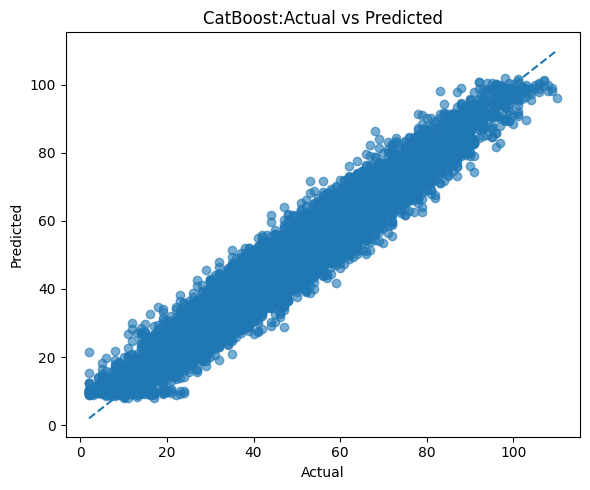

In [76]:
cat_clf, cat_reg = catboost_model(
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test
)

In [77]:
#PREDICTIONS

In [78]:
test_data = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\Project\TestData.csv")
test_data

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,latitude,longitude
0,14-04-2019,Bangladesh,Storm Surge,2.31,33,2313181.16,25.83,148615.11,-50.086,151.193
1,01-12-2023,Australia,Earthquake,1.39,24,1424976.69,42.94,57234.21,-14.528,158.150
2,24-05-2022,Spain,Storm Surge,4.78,100,4833417.53,3.14,453897.51,-47.960,-149.090
3,31-10-2022,Italy,Wildfire,5.35,92,198166.32,10.18,234529.87,41.775,154.956
4,10-06-2023,Mexico,Drought,4.58,102,5508586.18,7.73,307567.28,25.560,-55.279
5,01-09-2023,Philippines,Earthquake,5.57,2,11574699.59,2.77,119415.50,13.191,83.480
6,15-02-2024,Indonesia,Landslide,5.99,69,4792100.68,17.47,250953.91,32.926,34.321
7,22-12-2019,Chile,Landslide,2.58,81,1621695.18,15.85,161696.39,48.778,-160.892
8,28-01-2020,Spain,Extreme Heat,10.00,188,8415642.38,6.41,125595.75,24.811,4.073
9,27-07-2022,Philippines,Earthquake,1.53,34,2023222.48,21.91,115428.94,-1.388,-59.575


In [79]:
test_data["date"]=pd.to_datetime(test_data["date"],errors="coerce")
test_data["year"]=test_data["date"].dt.year
test_data["month"]=test_data["date"].dt.month

test_data.drop("date",axis=1,inplace=True)

In [80]:
test_data

,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,latitude,longitude,year,month
0,Bangladesh,Storm Surge,2.31,33,2313181.16,25.83,148615.11,-50.086,151.193,2019,4
1,Australia,Earthquake,1.39,24,1424976.69,42.94,57234.21,-14.528,158.150,2023,12
2,Spain,Storm Surge,4.78,100,4833417.53,3.14,453897.51,-47.960,-149.090,2022,5
3,Italy,Wildfire,5.35,92,198166.32,10.18,234529.87,41.775,154.956,2022,10
4,Mexico,Drought,4.58,102,5508586.18,7.73,307567.28,25.560,-55.279,2023,6
5,Philippines,Earthquake,5.57,2,11574699.59,2.77,119415.50,13.191,83.480,2023,9
6,Indonesia,Landslide,5.99,69,4792100.68,17.47,250953.91,32.926,34.321,2024,2
7,Chile,Landslide,2.58,81,1621695.18,15.85,161696.39,48.778,-160.892,2019,12
8,Spain,Extreme Heat,10.00,188,8415642.38,6.41,125595.75,24.811,4.073,2020,1
9,Philippines,Earthquake,1.53,34,2023222.48,21.91,115428.94,-1.388,-59.575,2022,7


In [81]:
for col in test_data.columns:
    if test_data[col].dtype == "object":
        test_data[col] = LE.fit_transform(test_data[col])
        #test_data[col] =df[col] = le.fit_transform(df[col]).transform(test_data[col])


In [82]:

# ----------------------------------------
# Scale numeric columns
# ----------------------------------------
num_cols = scaler.feature_names_in_
test_data[num_cols] = scaler.transform(test_data[num_cols])

pred_class = cat_clf.predict(test_data).ravel()
pred_reg = cat_reg.predict(test_data).ravel()

# ----------------------------------------
# Attach predictions to ORIGINAL data
# ----------------------------------------
test_data["pred_response_efficiency_score"] = pred_class
test_data["pred_recovery_days"] = pred_reg

# ----------------------------------------
# Final output (human-readable)
# ----------------------------------------
test_data.head(20)

,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,latitude,longitude,year,month,pred_response_efficiency_score,pred_recovery_days
0,-1.463393,0.176074,-1.392699,-1.039042,-0.843018,1.473916,-0.707868,-1.447589,1.535925,49.0,3.0,Medium,22.317597
1,-1.636370,-1.221118,-1.866236,-1.177394,-1.114765,3.321850,-1.345887,-0.424612,1.606641,53.0,11.0,Low,12.295020
2,0.439346,0.176074,-0.121354,-0.009087,-0.071952,-0.976676,1.423604,-1.386426,-1.516376,52.0,4.0,High,47.272018
3,-0.079583,0.874671,0.172034,-0.132067,-1.490107,-0.216333,-0.108014,1.195185,1.574175,52.0,9.0,High,52.767793
4,0.093393,-1.570417,-0.224297,0.021658,0.134616,-0.480941,0.401931,0.728691,-0.562811,53.0,5.0,High,45.078695
5,0.266370,-1.221118,0.285271,-1.515588,1.990543,-1.016637,-0.911739,0.372844,0.847639,53.0,8.0,High,53.996339
6,-0.252559,-0.173224,0.501451,-0.485633,-0.084593,0.571010,0.006658,0.940605,0.347951,54.0,1.0,High,59.512172
7,-0.944464,-0.173224,-1.253726,-0.301164,-1.054579,0.396045,-0.616535,1.396656,-1.636340,49.0,11.0,High,25.265211
8,0.439346,-0.871820,2.565457,1.343689,1.024030,-0.623505,-0.868589,0.707143,0.040487,50.0,0.0,High,99.397879
9,0.266370,-1.221118,-1.794176,-1.023669,-0.931731,1.050544,-0.939573,-0.046583,-0.606479,52.0,6.0,Medium,14.231491
